In [209]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")

#Long Exam Part II no.1

#First, we define the function for forward substitution and backward substitution.

def forsub(L, bs): #Function for forward sub
    n = bs.size
    xs = np.zeros(n)
    for i in range(n):
        xs[i] = (bs[i] - L[i,:i]@xs[:i])/L[i,i]
    return xs

def backsub (U, bs): #Function for backward sub
     n = bs.size
     xs = np.zeros(n)
     for i in reversed(range(n)):
        xs[i] = (bs[i] - U[i,i+1:]@xs[i+1:])/U[i,i]
     return xs

#We then define a function that decomposes a matrix into its LU components.

def ludec(A): #Function for LU Decomposition of a matrix A.
    n = A.shape[0]
    U = np.copy(A)
    L = np.identity(n)

    for j in range(n-1):
        for i in range(j+1,n):
             coeff = U[i,j]/U[j,j]
             U[i,j:]-= coeff*U[j,j:]
             L[i,j] = coeff
    return L, U
#We then define a function that partial pivots the augmented matrix.

def parpivot (infA, infbs):#Function that partial pivots some matrix infA and the constant vector infbs
    A = np.copy(infA)
    bs = np.copy(infbs)
    n = bs.size
    
    for j in range(n-1):
         k = np.argmax(np.abs(A[j:,j])) + j
         if k != j:
             A[j,:], A[k,:] = A[k,:], A[j,:].copy()
             bs[j], bs[k] = bs[k], bs[j]
    return A, bs

#We then define an LU decomposition function that replaces a U_ii element to 10^-20 if U_ii == 0

def ludec_safe (A): #Function for LU Decomposition with replacement of 10^-20 for Uii element of a matrix A.
    n = A.shape[0]
    U_rep = np.copy(A)
    L_rep = np.identity(n)

    for j in range(n-1):
        for i in range(j+1,n):
            coeff = U_rep[i,j]/U_rep[j,j]
            U_rep[i,j:] -= coeff*U_rep[j,j:] 
            if U_rep[i,i] == 0: #replaces U_ii elements 
                U_rep[i,i] = 1e-20 
            L_rep[i,j] = coeff
    return L_rep, U_rep

#Define the given:

A = np.array([4., 4, 8,4, 4, 5,3, 7, 8, \
 3, 9,9, 4, 7,9, 5]).reshape(4,4)
bs = np.array([1., 2, 3, 4])

#Solving A(xs) = bs using LU Decomp without pivoting

L_nopiv, U_nopiv = ludec(A) #Gives the L and U matrices for A
ys_nopiv = forsub(L_nopiv, bs) #forward subbing to get ys
xs_nopiv = backsub(U_nopiv, ys_nopiv) #backward subbing to get xs

print("xs without pivoting using LU Decomp:", xs_nopiv)

#Solving A(xs) = bs using LU Decomp with pivoting

A_piv, bs_piv = parpivot(A, bs) #Gives A and bs with partial pivot
L_piv, U_piv = ludec (A_piv) #Gives the L and U matrices for pivoted A
ys_piv = forsub(L_piv, bs_piv) #forward subbing to get ys
xs_piv = backsub(U_piv, ys_piv) #backward subbing to get xs

print("xs with pivoting using LU Decomp:" , xs_piv)

#Conclusion before proceeding with the replacement of Uii element  
print("\nConclusions: The nan and inf error comes from the fact that one of the U_ii (particularly U_33) is zero. Therefore, A is singular\n")

#Solving A(xs) = bs using LU Decomp without pivoting and with U_33 = 1e-20.

L_nopiv_safe, U_nopiv_safe = ludec_safe(A) #Gives the L and U matrices for A with U_33 replacement
ys_nopiv_safe = forsub(L_nopiv_safe, bs) #forward subbing to get ys
xs_nopiv_safe = backsub(U_nopiv_safe, ys_nopiv_safe) #backward subbing to get xs

print("xs without pivoting using LU Decomp (U_33 = 1e-20):", xs_nopiv_safe)

#Solving A(xs) = bs using LU Decomp with pivoting and with U_33 = 1e-20.

A_piv, bs_piv = parpivot(A, bs) #Gives A and bs with partial pivot
L_piv_safe, U_piv_safe = ludec_safe (A_piv) #Gives the L and U matrices for pivoted A with U_33 replacement
ys_piv_safe = forsub(L_piv_safe, bs_piv) #forward subbing to get ys
xs_piv_safe = backsub(U_piv_safe, ys_piv_safe) #backward subbing to get xs

print("xs with pivoting using LU Decomp (U_33 = 1e-20):" , xs_piv_safe)

#Additional observations
print("\nReplacing an element with a tiny number did not help since dividing by a tiny number amplifies the error")


             
    
            
    
    

xs without pivoting using LU Decomp: [nan nan inf inf]
xs with pivoting using LU Decomp: [ nan  inf -inf -inf]

Conclusions: The nan and inf error comes from the fact that one of the U_ii (particularly U_33) is zero. Therefore, A is singular

xs without pivoting using LU Decomp (U_33 = 1e-20): [-4.5e+20 -1.5e+20  1.5e+20  3.0e+20]
xs with pivoting using LU Decomp (U_33 = 1e-20): [ 9.e+20  3.e+20 -3.e+20 -6.e+20]

Replacing an element with a tiny number did not help since dividing by a tiny number amplifies the error


The odd thing about this result is that the central difference method should theoretically have a lower total error due to O(h^2). However, at higher h values, it shows that it has a higher error than the central difference approximation. This can be consolidated by the fact that f'''(x) that was used is of high value so it amplifies the central difference approximation. Likewise can be said for the forward difference approximation, which has a low value for f''(x). 

One possible form of the function that satisfies the values is:

f(x) = 1 + 0.05*x^2 + (50/3)*x^3


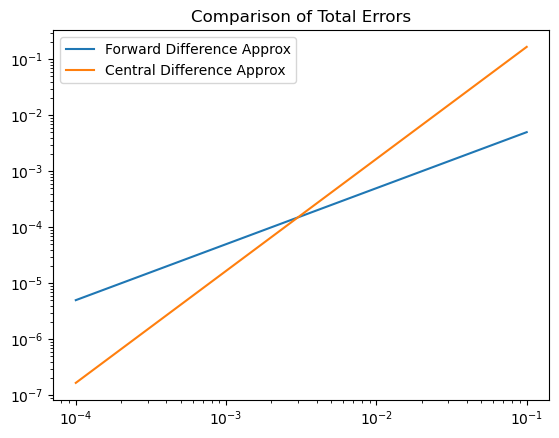

In [206]:
import numpy as np
import matplotlib.pyplot as plt

#Long Exam 1 Part II no.2

em = 2.2*1e-16 #machine precision value

#Defining the function for the total error in the forward difference

def for_err(h,second_df, f): #Function for the total error in the forward difference
    for_err = (h/2)*abs(second_df) + (2*abs(f)*em)/h
    return for_err

#Defining the function for the total error in the central difference

def cent_err(h,third_df, f): #Function for the total error in the central difference
    cent_err = ((h**2)/6)*abs(third_df) + (abs(f)*em)/h
    return cent_err

#Plotting

h_values = np.array([1e-1, 1e-2, 1e-3, 1e-4]) #values of h 
f = 1 #f(x) = 1
second_df = 0.1 #f''(x) = 0.1
third_df = 100 #f'''(x) = 100

plt.loglog(h_values, for_err(h_values, second_df,f), label = "Forward Difference Approx")
plt.loglog(h_values, cent_err(h_values, third_df,f), label = "Central Difference Approx")
plt.title("Comparison of Total Errors")
plt.legend()

#Insights

print("The odd thing about this result is that the central difference method should theoretically have a lower total error due to O(h^2). However, at higher h values, it shows that it has a higher error than the central difference approximation. This can be consolidated by the fact that f'''(x) that was used is of high value so it amplifies the central difference approximation. Likewise can be said for the forward difference approximation, which has a low value for f''(x). ")
print("\nOne possible form of the function that satisfies the is:")
print("\nf(x) = 1 + 0.05*x^2 + (50/3)*x^3")


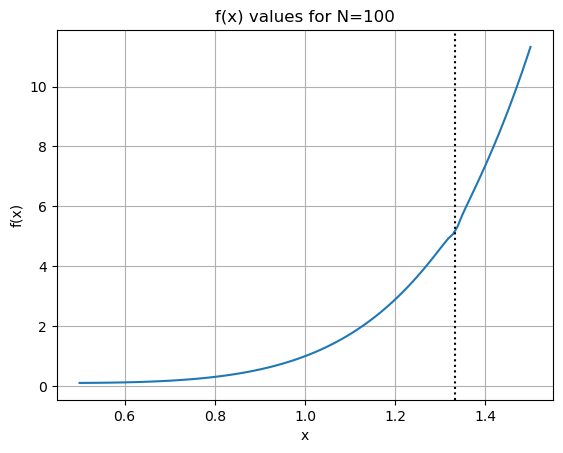

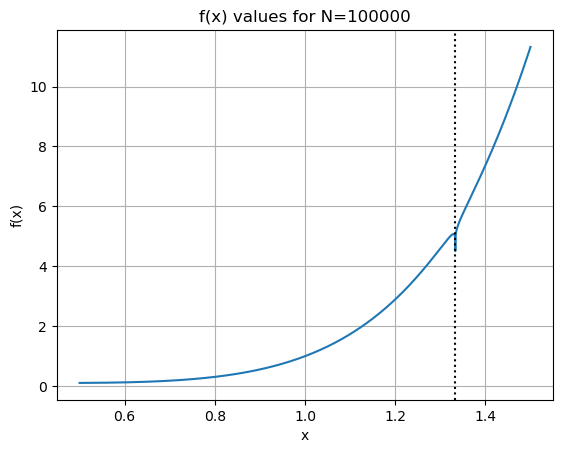

The behaviour of the function should drop down to negative infinity as x goes to 4/3. For N = 100, the 'dip' is not noticable. For N = 100000, the dip becomes noticable. This is due to the spacing of the points being closer for N = 100000 than N = 100 in the sense that it is finer.


In [207]:
import numpy as np
import matplotlib.pyplot as plt

#Long Exam 1 Part II no.3

#Define the function 
def f(x):
    f = x**6.0 + 0.1*np.log(abs(1.0 + 3.0*(1.0 - x)))
    return f

#Plotting
x_100 = np.linspace(0.5, 1.5, 100, endpoint=True) #100 points from x = 0.5 to 1.5
x_100000 = np.linspace(0.5, 1.5, 100000, endpoint=True) #100000 points from x = 0.5 to 1.5

plt.figure(1) #plot for N = 100
plt.plot(x_100, f(x_100))
plt.grid(True)
plt.title("f(x) values for N=100")
plt.axvline(x = 4/3 ,color = "k", linestyle = "dotted")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.figure(2) #plot for N = 100000
plt.plot(x_100000, f(x_100000))
plt.grid(True)
plt.title("f(x) values for N=100000")
plt.axvline(x = 4/3 ,color = "k", linestyle = "dotted")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.show()

#Explanation
print("The behaviour of the function should drop down to negative infinity as x goes to 4/3. For N = 100, the 'dip' is not noticable. For N = 100000, the dip becomes noticable. This is due to the spacing of the points being closer for N = 100000 than N = 100 in the sense that it is finer.")
